# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [30]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [32]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [33]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [34]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [35]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [36]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [37]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [38]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [39]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [40]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


En el dataset users la columna city tiene aproximadamente 11.7% de valores nulos-- Recomiendo imputar como investigar ya que puede ser relevante para segmentacion.
La Columna Churn_date tiene aproximadamente 88.3% de valores nulos- Indica clientes que no han hecho churn; recomiendo mantenerla y transformarla en variable binaria.
El resto de columnas no representan valores nulos- no requieren tratamiento.

En el dataset usage la columna date tiene aproximadamente 0.12%de valores nulos-Recomiendo elimanr esos registros ya que el impacto es minimo.
La columna lenght tiene aproximadamente 44.7% de valores nulos -No imputar ya que corresponde a registros que no son mensages.
La columna duration tiene aproximadamente 55.2%de valores nulos._ No imputar ya que corresponde a registros que no son llamadas.
El resto de columnas no representan  valores nulos.- No requieren tratamiento.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [41]:
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` no tiene valores nulos y parece ser identificator unico de cada usuario no requiere limpieza.
- La columna `age` no tiene nulos pero contiene el -999 este valor es invalido para analisis de edad recomiendo remplazarlo por la mediana de a columna.

In [42]:
# explorar columnas numéricas de usage
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`no tienen valores nulos y parecen idendtificadores unicos de registros y usarios 
- Las columnas no requieren limpieza.

In [43]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nColumna: {col}")
    print(users[col].value_counts())


Columna: city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64


In [44]:
# explorar columna categórica de usage
usage['type'].value_counts()


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` indica el tipo de actividad del registro usage por ejemplo calls or text. No tiene valores nulos no require limpieza pero es util separar datasets de llamadas y textos,


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [45]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [46]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, los años presentes van desde aproximadamente 2022-2024 lo cual coincide con el periodo de analisis definido para ConnectaTel.
Se puede usar para analisis de antiguedad del cliente, cohortes o tendencias de registro a lo largo del tiempo.

In [47]:
# Revisar los años presentes en `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date`, los valores estan correctamente convertidios a tipo año.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

Tras explorar las columnas de fecha en los datasets users (reg_date) y usage date no aparce años imposible no require eliminacion de registros.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [48]:

age_mediana = users.loc[users["age"] != -999, "age"].median()



users['age'].describe()


count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [49]:


# Marcar fechas futuras como NA para reg_date
import pandas as pd 

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

users.loc[users['reg_date'] > pd.Timestamp.today(), 'reg_date'] = pd.NaT


# Verificar cambios
print(users['reg_date'].isna().sum())



40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [50]:
import pandas as pd 

usage['duration_missing'] = usage['duration'].isna()



No imputar ni eliminar registros, porque los nulos reflejan correctamente la naturaleza estructural del servicio.
Esto permite análisis posteriores sin introducir sesgos artificiales.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [52]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage .groupby("user_id").agg(
    total_calls=("is_call", "sum"),
    total_texts=("is_text", "sum"),
    total_duration=("duration", "sum"),
    total_length=("length", "sum"),
    avg_duration=("duration", "mean"),
    avg_length=("length", "mean")
).reset_index()
  

# observar resultado
usage_agg.head(3)

,user_id,total_calls,total_texts,total_duration,total_length,avg_duration,avg_length
0,10000,3,7,23.70,258.0,7.900,36.857143
1,10001,10,5,33.18,226.0,3.318,45.200000
2,10002,2,5,10.74,225.0,5.370,45.000000


In [53]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,total_calls,total_texts,total_duration,total_length,avg_duration,avg_length
0,10000,3,7,23.70,258.0,7.900,36.857143
1,10001,10,5,33.18,226.0,3.318,45.200000
2,10002,2,5,10.74,225.0,5.370,45.000000


In [54]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile =  users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_calls,total_texts,total_duration,total_length,avg_duration,avg_length
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,7.900000,36.857143
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,3.318000,45.200000
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,5.370000,45.000000
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,2.996667,48.181818
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,2.670000,57.250000


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [55]:
# Resumen estadístico de las columnas numéricas
numerical_cols = user_profile.select_dtypes(include='number').columns
user_profile[numerical_cols].describe()

,user_id,age,total_calls,total_texts,total_duration,total_length,avg_duration,avg_length
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000,3999.000000,3958.000000,3981.000000
mean,11999.500000,33.739750,4.478120,5.524381,23.317054,288.128032,5.229795,52.249661
std,1154.844867,123.232257,2.144238,2.358416,18.168095,180.906841,3.892719,28.914064
min,10000.000000,-999.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000
25%,10999.750000,32.000000,3.000000,4.000000,11.120000,184.000000,3.175000,44.000000
50%,11999.500000,47.000000,4.000000,5.000000,19.780000,268.000000,4.650000,50.333333
75%,12999.250000,63.000000,6.000000,7.000000,31.415000,361.000000,6.421563,56.181818
max,13999.000000,79.000000,15.000000,17.000000,155.690000,2028.000000,120.000000,764.000000


In [56]:
# Distribución porcentual del tipo de plan
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100

print(plan_distribution.round(2))


Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

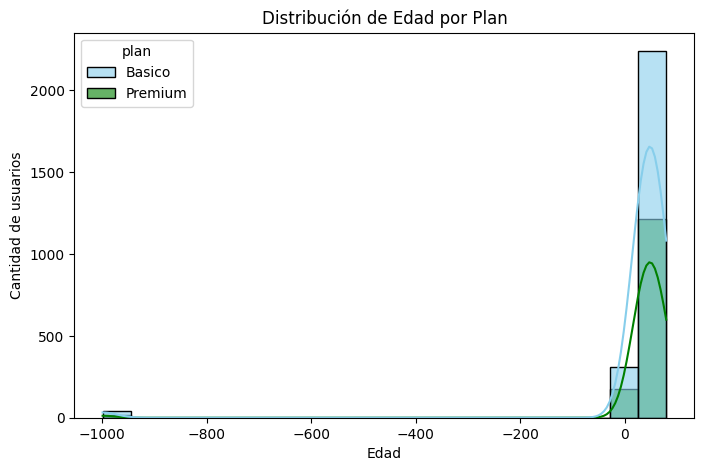

In [57]:

# Histograma para visualizar la edad (age)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',          
    bins=20,             
    palette=['skyblue','green'],
    kde=True,            
    alpha=0.6           
)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución ...

<AxesSubplot:xlabel='total_texts', ylabel='Count'>

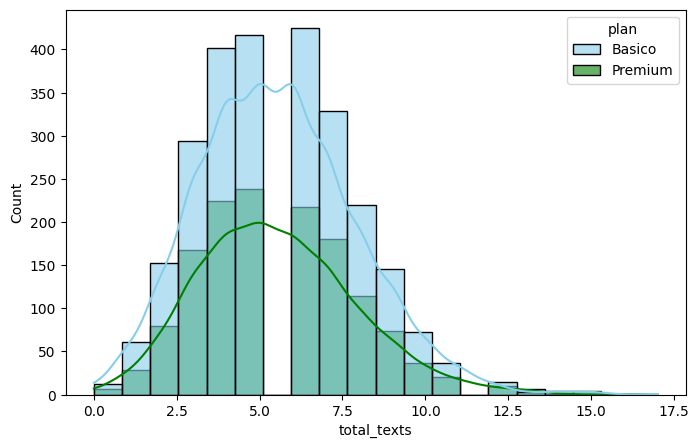

In [66]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='total_texts',  # o la columna correcta que quieras graficar
    hue='plan',
    bins=20,
    palette=['skyblue','green'],
    kde=True,
    alpha=0.6
)

💡Insights: 
- ....

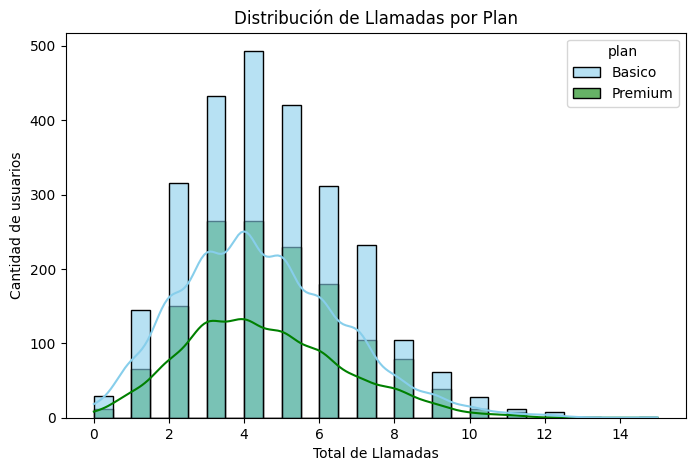

In [68]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='total_calls',  # ✅ Usa este nombre
    hue='plan',            
    bins=30,
    palette=['skyblue','green'],
    kde=True,              
    alpha=0.6               
)
plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Total de Llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución ...

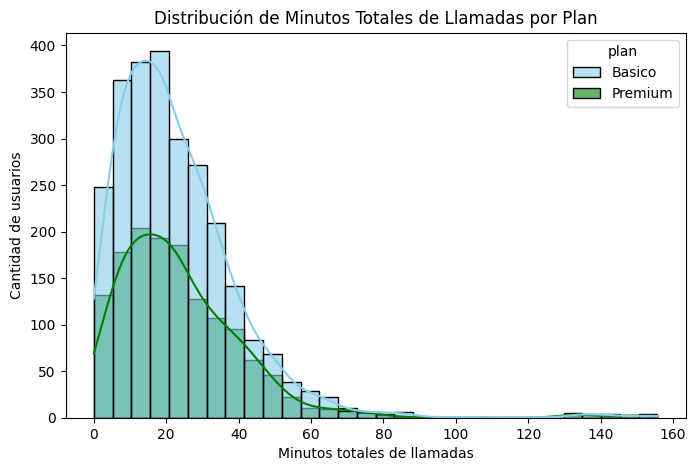

In [70]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='total_duration',  # ✅ Cambia aquí el nombre correcto
    hue='plan',
    bins=30,
    palette=['skyblue','green'],
    kde=True,
    alpha=0.6
)
plt.title('Distribución de Minutos Totales de Llamadas por Plan')
plt.xlabel('Minutos totales de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

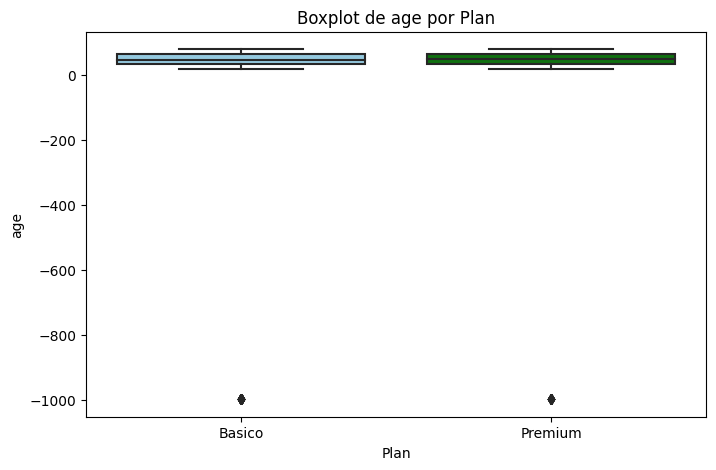

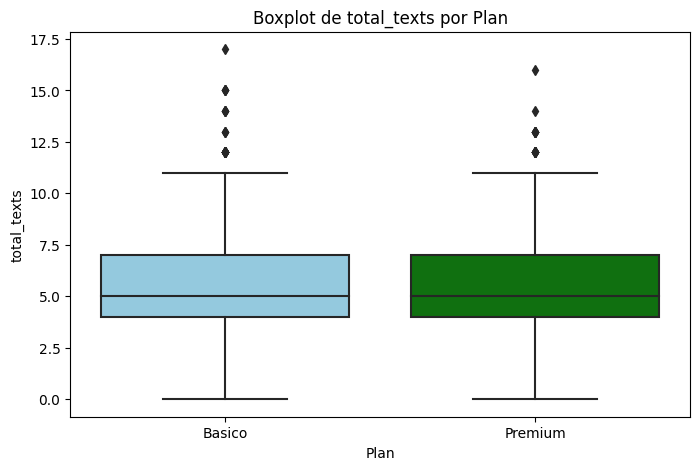

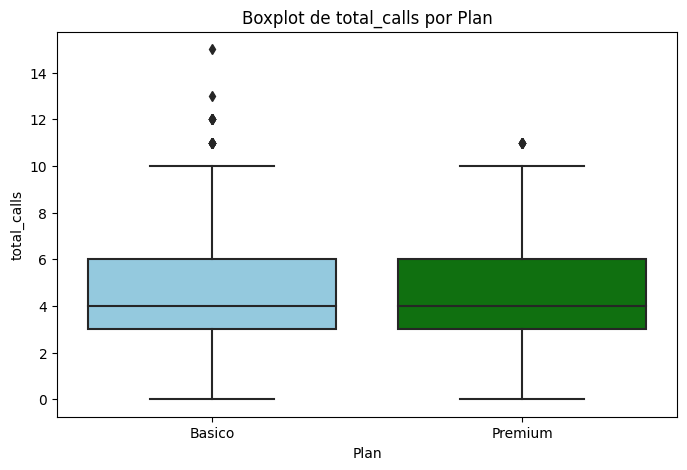

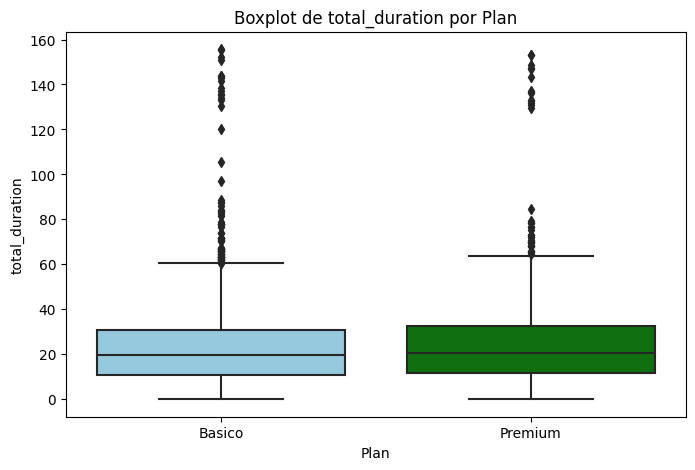

In [72]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'total_texts', 'total_calls', 'total_duration']

for col in columnas_numericas:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        x='plan', 
        y=col, 
        data=user_profile, 
        palette=['skyblue','green']
    )
    plt.title(f'Boxplot de {col} por Plan')
    plt.xlabel('Plan')
    plt.ylabel(col)
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [73]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'total_texts', 'total_calls', 'total_duration']


limites_outliers = {}

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    limites_outliers[col] = (limite_inferior, limite_superior)
    print(f"{col}: Limite inferior = {limite_inferior}, Limite superior = {limite_superior}")



age: Limite inferior = -14.5, Limite superior = 109.5
total_texts: Limite inferior = -0.5, Limite superior = 11.5
total_calls: Limite inferior = -1.5, Limite superior = 10.5
total_duration: Limite inferior = -19.322500000000005, Limite superior = 61.8575


In [74]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
resumen = user_profile[columnas_limites].describe().T  
resumen['limite_superior'] = [limites_outliers[col][1] for col in columnas_limites]
resumen['max'] = user_profile[columnas_limites].max().values

print(resumen[['count','mean','50%','max','limite_superior']])
user_profile[columnas_limites].describe()

                 count       mean    50%     max  limite_superior
age             4000.0  33.739750  47.00   79.00         109.5000
total_texts     3999.0   5.524381   5.00   17.00          11.5000
total_calls     3999.0   4.478120   4.00   15.00          10.5000
total_duration  3999.0  23.317054  19.78  155.69          61.8575


,age,total_texts,total_calls,total_duration
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,33.739750,5.524381,4.478120,23.317054
std,123.232257,2.358416,2.144238,18.168095
min,-999.000000,0.000000,0.000000,0.000000
25%,32.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [76]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso' 

user_profile.loc[
    (user_profile['total_calls'] < 5) & (user_profile['total_texts'] < 5),
    'grupo_uso'
] = 'Bajo uso'

user_profile.loc[
    (user_profile['total_calls'] < 10) & (user_profile['total_texts'] < 10) &
    ~((user_profile['total_calls'] < 5) & (user_profile['total_texts'] < 5)),
    'grupo_uso'
] = 'Uso medio'

print(user_profile['grupo_uso'].value_counts())

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [77]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_calls,total_texts,total_duration,total_length,avg_duration,avg_length,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,7.900000,36.857143,Uso medio
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,3.318000,45.200000,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,5.370000,45.000000,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,2.996667,48.181818,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,2.670000,57.250000,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [78]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'


user_profile.loc[(user_profile['age'] >= 30) & (user_profile['age'] < 60), 'grupo_edad'] = 'Adulto'

print(user_profile['grupo_edad'].value_counts())
user_profile.head()


Adulto          1963
Adulto Mayor    1222
Joven            815
Name: grupo_edad, dtype: int64


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_calls,total_texts,total_duration,total_length,avg_duration,avg_length,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,7.900000,36.857143,Uso medio,Adulto
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,3.318000,45.200000,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,5.370000,45.000000,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,2.996667,48.181818,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,2.670000,57.250000,Bajo uso,Adulto Mayor


In [79]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_calls,total_texts,total_duration,total_length,avg_duration,avg_length,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,7.900000,36.857143,Uso medio,Adulto
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,3.318000,45.200000,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,5.370000,45.000000,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,2.996667,48.181818,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,2.670000,57.250000,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

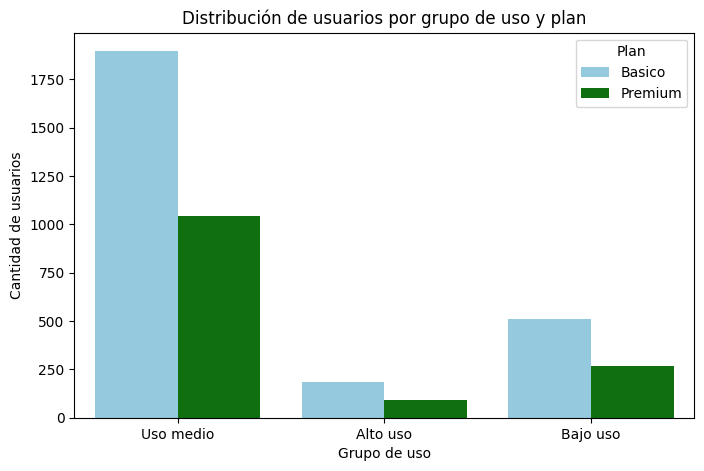

In [80]:

# Visualización de los segmentos por uso
plt.figure(figsize=(8,5))
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    hue='plan',          
    palette=['skyblue','green']
)
plt.title('Distribución de usuarios por grupo de uso y plan')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Plan')
plt.show()


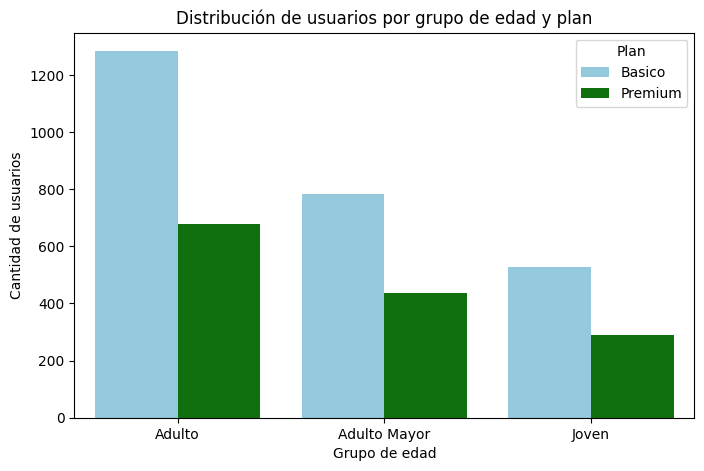

In [81]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8,5))
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    hue='plan',          
    palette=['skyblue','green']
)
plt.title('Distribución de usuarios por grupo de edad y plan')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Plan')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- age tenia el valor -999 fue remplazado por la mediana.
- reg_date y date contenian años futuros o fuera de rango fueron marcadas como NA. 
- city tenia "?" fue remplazados por valores nulos (pd.NA).


🔍 **Segmentos por Edad**
- Joven: <30 años
- Adulto: 30-59 años
- Adulto Mayor >60 años


📊 **Segmentos por Nivel de Uso**
- Los usuarios jovenes tienden a conectarse en Bajo o Uso medio.
- Los adultos muestran mas dispersion, muchos en uso medio o alto uso.
- Los adulots mayores son pocos, con mayoria en Bajo uso.
- Los altos usuarios suelen permanecer en plan Premium, mientras que los Bajo usuarios predominan el plan basico.



➡️ Esto sugiere que algunos usuarios presentan consumo muy alto de minutos y mensajes, muy por encima de los límites IQR.
Implicaciones Indican clientes premium o heavy users que pueden generar ingresos significativos, también pueden alertar sobre uso inusual o fraude (por ejemplo, llamadas internacionales masivas).


💡 **Recomendaciones**
- Planes personalizados según segmentos.
- Crear un plan “Premium alto uso” con más minutos y mensajes ilimitados para heavy users.
- Ofrecer un plan “Uso medio” para jóvenes y adultos que consumen moderadamente.
- Campañas segmentadas diseñar campañas según edad y nivel de uso: jóvenes pueden ser más sensibles a promociones digitales, adultos a planes familiares o flexibles.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`